## Financial Engineering - Group 7B
<hr>

### The Additive Bachelier Model

Our work is based on some fundamental numerical python libraries, like `numpy` or `pandas`, and many custom-written code to calibrate and price financial instruments. We import all the relevant methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from calibration.bootstrap import ETL, bootstrap, zero_rates, sigma_atm
from utils.utils import year_frac_act_x, generate_full_grid

Extracting, transform and loading the options data is handled by the `ETL` class. This object, and its associated method, is responsible for reading all the files in the specified paths

In [2]:
dataLoader = ETL.load("Data/datacalls", "Data/dataputs")
strikes = dataLoader.strikes

expiries = [datetime(2020, 8, 17), datetime(2020, 11, 17),
            datetime(2021, 2, 17),  datetime(2021, 5, 17), datetime(2021, 8, 17),
            datetime(2021, 11, 16), datetime(2022, 5, 17), datetime(2022, 11, 16)]

## Bootstrap

Our analysis starts on the $02-06-2020$

In [3]:
today = pd.to_datetime("2020-06-02")
prices_call, prices_put, prices_fwd = dataLoader.value_date(20200602)

In [6]:
print(prices_fwd)

[[  nan 32.35 31.84 ...   nan   nan   nan]
 [  nan   nan 32.41 ...   nan   nan   nan]
 [  nan   nan   nan ...   nan   nan   nan]
 ...
 [  nan   nan   nan ...   nan   nan   nan]
 [  nan   nan   nan ...   nan   nan   nan]
 [  nan   nan   nan ...   nan   nan   nan]]


Discounts factors and zero rates are computed using the `bootstrap` library, which can be found in the `calibration` folder. It applies the very same method of the $\texttt{MATLAB}$ version.

In [16]:
discounts, fwd_atm, call_atm = bootstrap(prices_call, prices_put, strikes)
zeroRates = zero_rates(discounts, expiries, today)

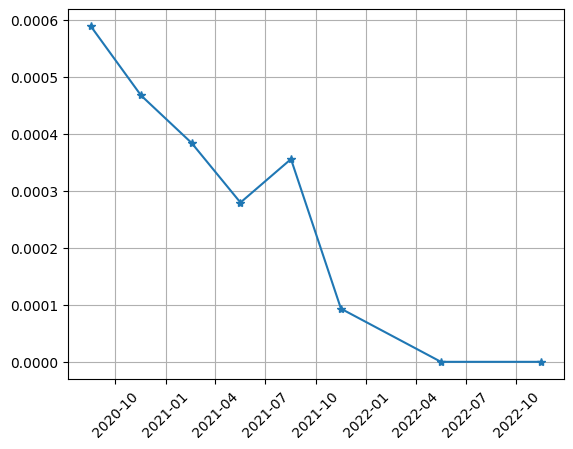

In [17]:
plt.plot(expiries, zeroRates, label="Zero Rates", marker='*')
plt.xticks(rotation=45)
plt.grid()

The volatility term structure of the Bachelier model is the fundamental building block for the later additive extension. We compute it with the function `sigma_atm` from the `bootstrap.py` module

In [18]:
sigmaATM = sigma_atm(call_atm, discounts, expiries, today)

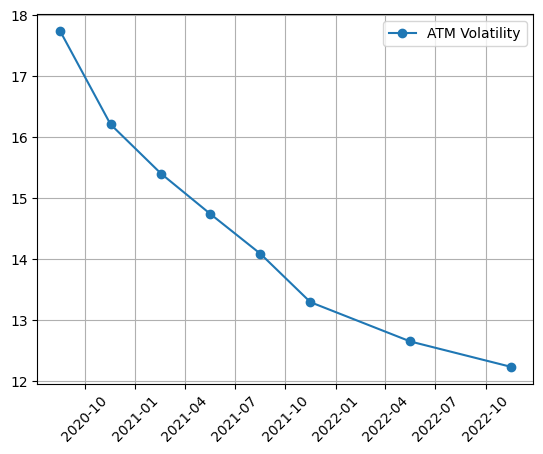

In [19]:
plt.plot(expiries, sigmaATM, marker='o', label="ATM Volatility")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

In [20]:
yf = np.array([year_frac_act_x(today, d) for d in expiries])

In [21]:
moneyness = np.zeros((len(strikes), len(expiries)))
for i in range(len(expiries)):
    moneyness[:,i] = strikes - fwd_atm[i]

## Bachelier Model: Implied Volatility

Before calibrating, we generate a full grid of options, using data from both calls and puts. Whenever the call for a specific strike-maturity pair is not traded, we check if the corresponding put has been sold. If so, we infer the price with put-call parity. If both options were not traded, then we just discard the point. This has been implemented in the `utils.generate_full_grid` method.

In [23]:
from pricing.bachelier import impliedVolatilityBachelier

In [24]:
marketMoneyness = {}
marketVols = {}

mkt_strikes = np.array([])
moneyness_norm = np.array([])
mkt_calls = np.array([])
prices_norm = np.array([])
J_index = np.array([])

for k in range(len(expiries)):
    tmp_calls, tmp_puts, tmp_K = generate_full_grid(prices_call[k,:], prices_put[k,:], strikes, fwd_atm[k], discounts[k])
    moneynesssRed, impvol = impliedVolatilityBachelier(moneyness[:,k], prices_call[k,:], yf[k], discounts[k])
    
    tmp_money = tmp_K - fwd_atm[k]
    mask = (tmp_money > -30) & (tmp_money < 30)

    marketMoneyness[expiries[k]] = moneynesssRed[mask]
    marketVols[expiries[k]] = impvol[mask]
    mkt_K = tmp_K[mask]
    calls = tmp_calls[mask]

    mkt_strikes = np.append(mkt_strikes, mkt_K)
    mkt_calls = np.append(mkt_calls, calls)
    prices_norm = np.append(prices_norm, calls/(sigmaATM[k]*np.sqrt(yf[k])*discounts[k]))
    moneyness_norm = np.append(moneyness_norm, moneynesssRed[mask]/(sigmaATM[k]*np.sqrt(yf[k])*discounts[k]))

    J_index = np.append(J_index, k*np.ones(len(moneynesssRed[mask])))

As done in the paper by Massaria, we restrict our calibration to instruments with moneyness in the $[-30,30]$ interval.

## Additive Bachelier Model: Calibration

The Additive Bachelier Model depends on two parameters: $\kappa$ and $\eta$. To compute these, we minimze the distance between the observed market prices and the model one.

In [12]:
from calibration.calibration import calibrateAddBachelier

In [13]:
kappa, eta, I0 = calibrateAddBachelier(prices_norm, moneyness_norm)
sigmat = sigmaATM/I0

Once $\kappa$,$\eta$ have been found, we can define the model volatility term structure

$$
    \sigma_t = \frac{sigma_{ATM}}{I_0}
$$


In [14]:
kappa, eta

(np.float64(0.8645109317387181), np.float64(-0.0052556050406792915))

## Additive Logistic Model: Calibration

The same procedure described before applies to the calibration of the Additive Logistic Model. Minimizing the distance in prices, we get to calibrate the $sigma$ and $H$ parameters

In [15]:
from calibration.calibration import calibrateAddLogistic

In [16]:
sigma, H = calibrateAddLogistic(mkt_calls, mkt_strikes, fwd_atm, yf, J_index)
sigma, H

(np.float64(8.317870074048553), np.float64(0.33485759533463233))

In the _Self-Similar Additive Logistic Model_, the volatility term structure depends on the two parameters calibrated above, through the relation

$$
\sigma_{ADL}(T) = \sigma T^H \log(2) \sqrt{\frac{2\pi}{T}}
$$

As we can see in the plot below, the logistic model is able to fit almost perfectly the current term structure of the market.

In [17]:
sigmaADL = sigma*yf**H*np.sqrt(2*np.pi/yf)*np.log(2)

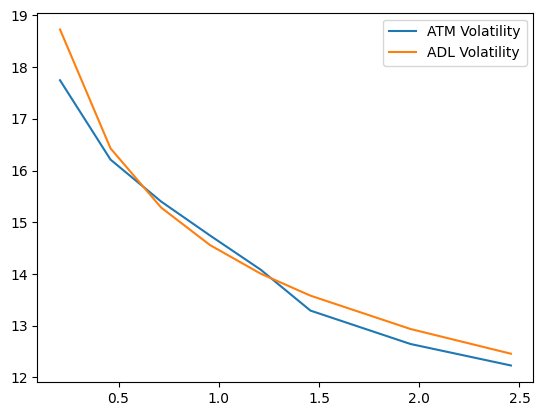

In [18]:
plt.plot(yf, sigmaATM, label="ATM Volatility")
plt.plot(yf, sigmaADL, label="ADL Volatility")
plt.legend()

## Implied Vol - Market vs Additive Bachelier

We now analyze the volatility surface of the Additive Bachelier Model. For each of one the eight maturities under consideration, we compare the market implied vol, computed some cells ago, with the Additive Bachelier One. This requires a high numbers of minimization procedure, so the execution may take a few.

In [19]:
from scipy.interpolate import interp1d
from pricing.smile import smileBachelier

In [20]:
moneynessRed, impvol = smileBachelier(kappa, eta)

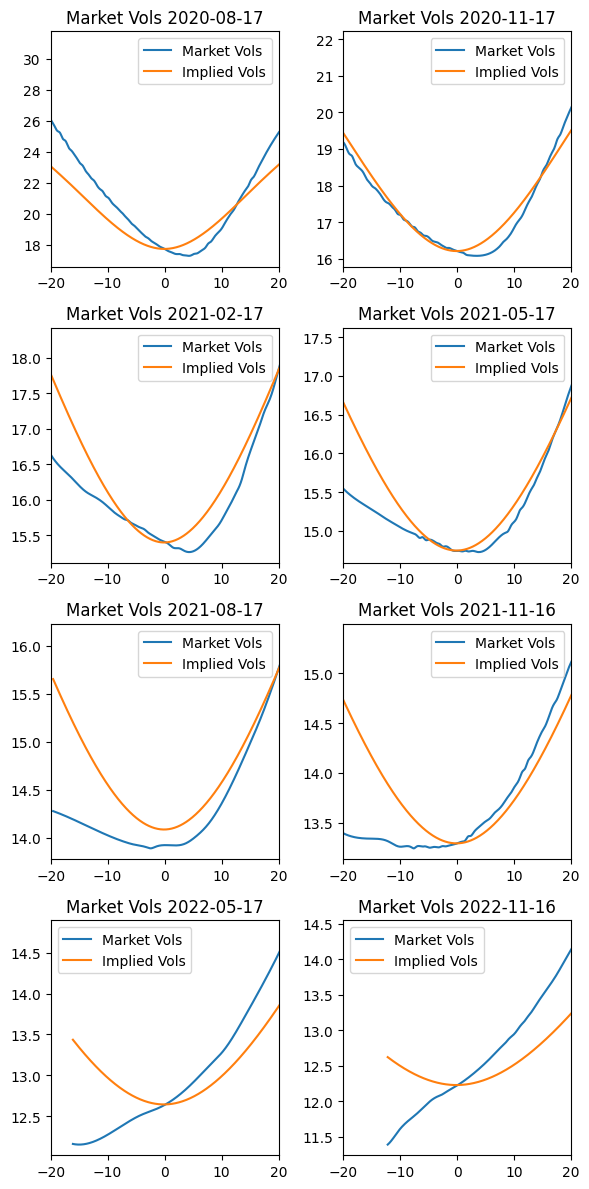

In [21]:
fig, ax = plt.subplots(4, 2, figsize=(6, 12))
ax = ax.flatten()

for i,date in enumerate(expiries):
    I = impvol*sigmaATM[i]
    x = moneynessRed*np.sqrt(yf[i])*sigmaATM[i]

    q = marketMoneyness[date]
    p = marketVols[date]

    if i == 7:
        q = q[1:]
        p = p[1:]

    x_interp = np.arange(min(q), 22, 0.1)

    interpolator1 = interp1d(x, I, kind='cubic', fill_value='extrapolate')
    interpolator2 = interp1d(q, p, kind='cubic', fill_value='extrapolate')
    I_interp = interpolator1(x_interp)
    p_interp = interpolator2(x_interp)

    ax[i].plot(x_interp, p_interp, label="Market Vols")
    ax[i].plot(x_interp, I_interp, label="Implied Vols")
    ax[i].set_title(f"Market Vols {date.strftime('%Y-%m-%d')}")
    ax[i].set_xlim(-20, 20)
    ax[i].legend()
    
plt.tight_layout()

## Pricing an Asian Digital

Let $F(t_i,t_N)$ be the value of the forward, expiring in $t_N$ November $16th$ 2022, at time $t_i$. Our contract pays $1 \$$ if the mean of the forward is above a certain strike $K$, taken equal to $F(t_0,t_N)$

\begin{equation*}
    \text{Payoff} = \mathbb{I}_{\Big\{ K > \frac{1}{N}\sum_{i=1}^N F(t_i,t_N) \Big\} }
\end{equation*}

We price this contract using the two models calibrated above. This is done using a particular Monte Carlo technique, described in the paper _"Roberto Baviera Michele Azzone. A fast monte carlo scheme for additive process
and option pricing"_. 

The code can be found in the `pricing.callMC` module. We've managed to develop a quite general framework, in which one can describe any kind of payoff, either path-dependent or not, and price the associated instrument.

In [4]:
from pricing.callMC import priceAsianDigital

In [5]:
paramsAB = {
    "kappa": kappa,
    "eta": eta,
    "B": discounts[-1],
    "yf": yf,
    "F0": fwd_atm[-1],
    "sigmat": sigmat,
}

paramsADL = {
    "sigma": sigma,
    "H": H,
    "B": discounts[-1],
    "F0": fwd_atm[-1],
    "yf": yf,
}

priceAB, CI_AB = priceAsianDigital("AddBachelier",paramsAB)
priceAL, CI_AL = priceAsianDigital("AddLogistic",paramsADL)

print(f"Bachelier: {priceAB} - CI: {CI_AB}")
print(f"Price Logistic: {priceAL} - CI: {CI_AL}")

NameError: name 'kappa' is not defined

## Hedging

In [24]:
from hedging import greeksASIAN, greeksEU

In [25]:
sigmacall = 12.2244

call_delta = greeksEU.delta(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 42)
call_vega = greeksEU.vega(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 42)
call_kappa = greeksEU.kappaCall(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 42)
call_eta = greeksEU.etaCall(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 42)

put_delta = greeksEU.delta(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 40) - discounts[-1]
put_vega = greeksEU.vega(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 40)
put_kappa = greeksEU.kappaCall(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 40)
put_eta = greeksEU.etaCall(kappa, eta, yf[-1], sigmacall, discounts[-1], fwd_atm[-1], 40)

A = np.array([[call_delta, call_vega, call_eta, call_kappa],
              [put_delta, put_vega, put_eta, put_kappa]])
A = np.vstack((np.ones(A.shape[1]), A)).T
A

array([[ 1.00000000e+00,  5.04973020e-01, -4.44327503e-01],
       [ 1.00000000e+00,  6.25368037e-01,  6.20529635e-01],
       [ 1.00000000e+00,  3.07084906e-02,  3.66882451e-01],
       [ 1.00000000e+00, -9.74676226e-05,  1.05901953e-02]])

In [28]:
b = np.array([
        greeksASIAN.sensDelta(kappa, eta, yf, sigmaATM, discounts[-1], fwd_atm[-1], fwd_atm[-1], priceAB),
        greeksASIAN.sensVol(kappa, eta, yf, sigmaATM, discounts[-1], fwd_atm[-1], fwd_atm[-1], priceAB),
        greeksASIAN.sensEta(kappa, eta, yf, sigmaATM, discounts[-1], fwd_atm[-1], fwd_atm[-1], priceAB),
        greeksASIAN.sensKappa(kappa, eta, yf, sigmaATM, discounts[-1], fwd_atm[-1], fwd_atm[-1], priceAB)
])
b

array([ 0.03557, -0.0038 ,  0.1478 ,  0.0005 ])

In [50]:
x_hedge = np.linalg.lstsq(A,b)[0]
x_hedge

array([ 1450147.5773169 , -2041633.22269608,   473317.29997753])

In [ ]:
price_call_liquid = 7.73
price_put_liquid = 6.54

x_fwd = np.floor(x_hedge[0]/fwd_atm[-1])
x_call = np.floor(x_hedge[1]/(price_call_liquid))
x_put = np.floor(x_hedge[2]/(price_put_liquid))

print(f"Fwd: {x_fwd}, Call: {x_call}, Put: {x_put}")

Fwd: 34379.0, Call: -264119.0, Put: 72372.0
